In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

def load_data(csv_path):
    df = pd.read_csv(csv_path)
    X, y = [], []
    for _, row in df.iterrows():
        img = np.load(row['file_path'])
        X.append(img)
        y.append(row['label'])
    return np.array(X), np.array(y)

# Încarcă datele
X_train, y_train = load_data("data/train.csv")
X_val, y_val = load_data("data/val.csv")
X_test, y_test = load_data("data/test.csv")

# Etichete one-hot
le = LabelEncoder()
y_train_enc = to_categorical(le.fit_transform(y_train))
y_val_enc = to_categorical(le.transform(y_val))
y_test_enc = to_categorical(le.transform(y_test))

print("Clase:", le.classes_)


Clase: ['acnes' 'blackheads' 'darkspots' 'wrinkles']


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


C:\Users\Alexandra\Desktop\Facultate anul 2\Semestrul 2\AI\ai-projects-powderpuff\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train_enc,
    validation_data=(X_val, y_val_enc),
    epochs=70,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 605ms/step - accuracy: 0.6298 - loss: 0.7583 - val_accuracy: 0.6750 - val_loss: 0.6669
Epoch 2/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 568ms/step - accuracy: 0.6765 - loss: 0.6940 - val_accuracy: 0.6875 - val_loss: 0.6655
Epoch 3/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 590ms/step - accuracy: 0.6676 - loss: 0.7054 - val_accuracy: 0.7625 - val_loss: 0.5857
Epoch 4/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 588ms/step - accuracy: 0.7614 - loss: 0.6313 - val_accuracy: 0.7375 - val_loss: 0.5947
Epoch 5/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 580ms/step - accuracy: 0.7392 - loss: 0.6209 - val_accuracy: 0.7188 - val_loss: 0.5909
Epoch 6/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 594ms/step - accuracy: 0.7143 - loss: 0.6139 - val_accuracy: 0.6687 - val_loss: 0.6620
Epoch 7/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 613ms/step - accuracy: 0.7225 - loss: 0.6543 - val_accuracy: 0.7563 - val_loss: 0.5618
Epoch 8/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 619ms/step - accuracy: 0.7567 - loss: 0.5957 - val_accu

In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test_enc)
print(f"Test Accuracy: {test_acc:.2f}")


model.save("skin_condition_cnn_model.h5")



7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.8300 - loss: 0.4505


Test Accuracy: 0.81


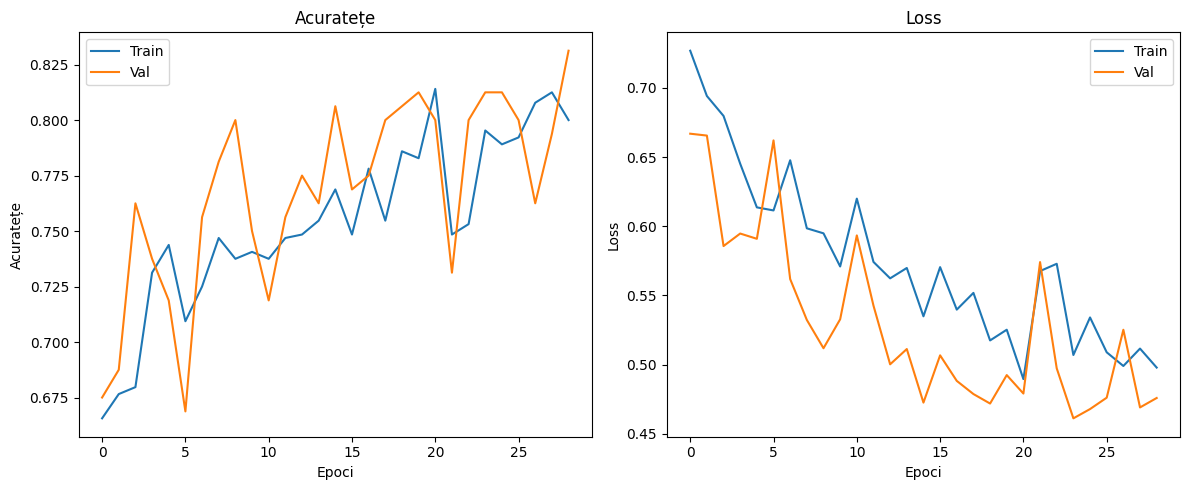

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Acuratețe')
plt.xlabel('Epoci')
plt.ylabel('Acuratețe')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.xlabel('Epoci')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
